In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("online_learning_raw.csv")

print("Shape:", df.shape)
print("Missing Values:\n", df.isnull().sum())

Shape: (80, 17)
Missing Values:
 Student_ID                   0
Gender                       0
Academic_Year                0
Q1_interruptions             0
Q2_short_sessions_pct        0
Q3_task_switching            0
Q4_duration_variability      0
Q5_daily_sessions            0
Q6_focus_difficulty          0
Q7_pause_freq                0
Q8_replay_freq               0
Q9_content_replayed_pct      0
Q10_replay_time_ratio        0
Q11_replay_reliance          0
Learning_Effectiveness       0
Course_Satisfaction          0
Self_Reported_Performance    0
dtype: int64


In [2]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# LFI components
lfi_cols = [
    "Q1_interruptions",
    "Q2_short_sessions_pct",
    "Q3_task_switching",
    "Q4_duration_variability",
    "Q5_daily_sessions",
    "Q6_focus_difficulty"
]

for col in lfi_cols:
    df["N_" + col] = normalize(df[col])

# RDP components
rdp_cols = [
    "Q7_pause_freq",
    "Q8_replay_freq",
    "Q9_content_replayed_pct",
    "Q10_replay_time_ratio",
    "Q11_replay_reliance"
]

for col in rdp_cols:
    df["P_" + col] = normalize(df[col])


In [5]:
df.head()

,Student_ID,Gender,Academic_Year,Q1_interruptions,Q2_short_sessions_pct,Q3_task_switching,Q4_duration_variability,Q5_daily_sessions,Q6_focus_difficulty,Q7_pause_freq,...,N_Q2_short_sessions_pct,N_Q3_task_switching,N_Q4_duration_variability,N_Q5_daily_sessions,N_Q6_focus_difficulty,P_Q7_pause_freq,P_Q8_replay_freq,P_Q9_content_replayed_pct,P_Q10_replay_time_ratio,P_Q11_replay_reliance
0,1,Male,3,7.15,30.74,8.99,2.73,1.62,6.72,9.10,...,0.374705,0.948130,0.547884,0.093379,0.619178,0.714414,0.000000,0.990401,0.710526,0.226027
1,2,Female,4,5.30,49.26,9.11,3.49,6.42,7.22,3.45,...,0.648022,0.962606,0.717149,0.908319,0.687671,0.205405,0.312242,0.175538,0.149123,0.679452
2,3,Male,1,3.05,49.35,8.78,3.24,4.03,5.41,2.57,...,0.649351,0.922799,0.661470,0.502547,0.439726,0.126126,0.198074,0.052065,0.578947,0.009589
3,4,Male,4,0.99,42.50,4.15,1.49,5.96,6.71,1.17,...,0.548259,0.364294,0.271715,0.830221,0.617808,0.000000,0.317744,0.778069,0.609649,0.095890
4,5,Male,3,2.89,11.32,1.13,4.59,2.92,6.38,5.03,...,0.088105,0.000000,0.962138,0.314092,0.572603,0.347748,0.103164,0.598749,0.425439,0.810959


In [3]:
df["LFI"] = df[[ "N_" + col for col in lfi_cols ]].mean(axis=1)

df[['Student_ID','LFI']].head()


,Student_ID,LFI
0,1,0.576435
1,2,0.758957
2,3,0.584576
3,4,0.448442
4,5,0.374547


In [4]:
df['LFI'].describe()

count    80.000000
mean      0.514090
std       0.130387
min       0.144243
25%       0.438729
50%       0.507737
75%       0.601834
max       0.860556
Name: LFI, dtype: float64

In [5]:
df["RDP"] = df[[ "P_" + col for col in rdp_cols ]].mean(axis=1)
df[['Student_ID','RDP']].head()

,Student_ID,RDP
0,1,0.528274
1,2,0.304352
2,3,0.192960
3,4,0.360270
4,5,0.457212


In [6]:
df['RDP'].describe()

count    80.000000
mean      0.471519
std       0.145024
min       0.118063
25%       0.370173
50%       0.482275
75%       0.578734
max       0.779576
Name: RDP, dtype: float64

In [7]:
def classify(row):
    if row["LFI"] >= 0.65 and row["RDP"] >= 0.60:
        return "High Risk"
    elif row["LFI"] >= 0.65 or row["RDP"] >= 0.60:
        return "Moderate Risk"
    else:
        return "Low Risk"

df["Risk_Category"] = df.apply(classify, axis=1)

df['Risk_Category'].value_counts()

Risk_Category
Low Risk         52
Moderate Risk    24
High Risk         4
Name: count, dtype: int64

In [8]:
(df['Risk_Category'].value_counts(normalize=True)*100)

Risk_Category
Low Risk         65.0
Moderate Risk    30.0
High Risk         5.0
Name: proportion, dtype: float64

In [9]:
corr_matrix = df[[
    "LFI",
    "RDP",
    "Learning_Effectiveness",
    "Course_Satisfaction",
    "Self_Reported_Performance"
]].corr()

print("Correlation Matrix:\n", corr_matrix)

Correlation Matrix:
                                 LFI       RDP  Learning_Effectiveness  \
LFI                        1.000000 -0.102822                0.083200   
RDP                       -0.102822  1.000000                0.091689   
Learning_Effectiveness     0.083200  0.091689                1.000000   
Course_Satisfaction       -0.103659 -0.016222               -0.004109   
Self_Reported_Performance  0.151261 -0.001314                0.071030   

                           Course_Satisfaction  Self_Reported_Performance  
LFI                                  -0.103659                   0.151261  
RDP                                  -0.016222                  -0.001314  
Learning_Effectiveness               -0.004109                   0.071030  
Course_Satisfaction                   1.000000                  -0.087541  
Self_Reported_Performance            -0.087541                   1.000000  


In [10]:
risk_counts = df["Risk_Category"].value_counts()
print("\nRisk Distribution:\n", risk_counts)

accuracy_baseline = (risk_counts["Low Risk"] / len(df)) * 100
print("\nLow Risk Percentage:", accuracy_baseline)


Risk Distribution:
 Risk_Category
Low Risk         52
Moderate Risk    24
High Risk         4
Name: count, dtype: int64

Low Risk Percentage: 65.0


In [11]:
df.to_csv("online_learning_processed.csv", index=False)
print("Processed Dataset Saved!")

Processed Dataset Saved!


In [12]:
df['LFI'] = (
    df['Q1_interruptions'] +
    df['Q2_short_sessions_pct'] +
    df['Q3_task_switching'] +
    df['Q4_duration_variability'] +
    df['Q5_daily_sessions'] +
    df['Q6_focus_difficulty']
) / 6

In [13]:
df['RDP'] = (
    df['Q7_pause_freq'] +
    df['Q8_replay_freq'] +
    df['Q9_content_replayed_pct'] +
    df['Q10_replay_time_ratio'] +
    df['Q11_replay_reliance']
) / 5

In [14]:
df['Learning Effectiveness'] = (
    df['Learning_Effectiveness'] +
    df['Course_Satisfaction'] +
    df['Self_Reported_Performance']
) / 3

In [15]:
def classify_risk(row):
    if row['LFI'] < 0.65 and row['RDP'] < 0.60:
        return 'Low Risk'
    elif row['LFI'] >= 0.65 and row['RDP'] >= 0.60:
        return 'High Risk'
    else:
        return 'Moderate Risk'

df['Risk Category'] = df.apply(classify_risk, axis=1)

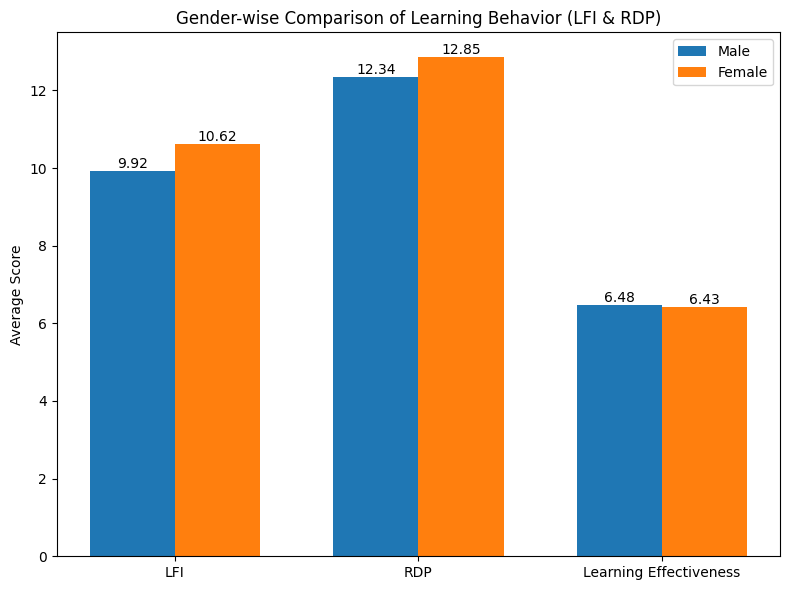

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Safe sampling (avoids error if less than 50 rows)
male_sample = df[df['Gender'] == 'Male'].sample(
    min(50, len(df[df['Gender'] == 'Male'])), random_state=1)

female_sample = df[df['Gender'] == 'Female'].sample(
    min(50, len(df[df['Gender'] == 'Female'])), random_state=1)

# Use correct column name (IMPORTANT)
columns = ['LFI', 'RDP', 'Learning Effectiveness']  # make sure this exists

# Compute averages
avg_scores_sample = pd.DataFrame({
    'Male': male_sample[columns].mean(),
    'Female': female_sample[columns].mean()
})

# Metrics
metrics = columns
x = np.arange(len(metrics))
width = 0.35

male_scores = avg_scores_sample['Male'].values
female_scores = avg_scores_sample['Female'].values

fig, ax = plt.subplots(figsize=(8,6))

# Plot bars
bars1 = ax.bar(x - width/2, male_scores, width, label='Male')
bars2 = ax.bar(x + width/2, female_scores, width, label='Female')

# Add value labels (VERY IMPORTANT)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.2f}', ha='center', va='bottom')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.2f}', ha='center', va='bottom')

# Labels
ax.set_ylabel('Average Score')
ax.set_title('Gender-wise Comparison of Learning Behavior (LFI & RDP)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
# Select only required columns
corr_cols = df[['LFI', 'RDP', 'Learning Effectiveness']]

# Compute correlation
correlation_matrix = corr_cols.corr(method='pearson')

print(correlation_matrix)

                             LFI       RDP  Learning Effectiveness
LFI                     1.000000  0.117471                0.025828
RDP                     0.117471  1.000000               -0.065320
Learning Effectiveness  0.025828 -0.065320                1.000000


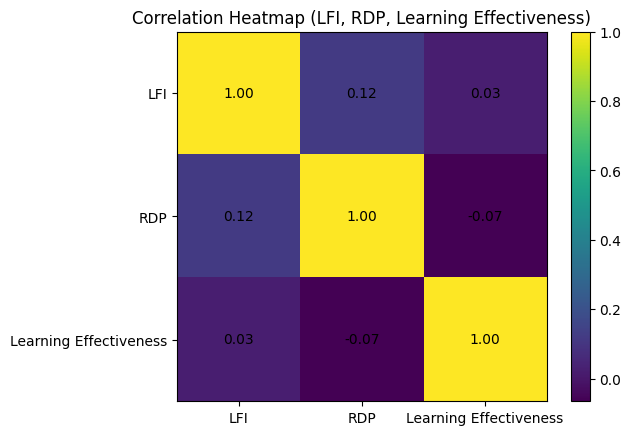

In [18]:
import matplotlib.pyplot as plt

# Select columns
corr_cols = df[['LFI', 'RDP', 'Learning Effectiveness']]

# Compute correlation
correlation_matrix = corr_cols.corr()

# Plot heatmap
fig, ax = plt.subplots()

cax = ax.imshow(correlation_matrix)

# Add color bar
plt.colorbar(cax)

# Labels
ax.set_xticks(range(len(corr_cols.columns)))
ax.set_yticks(range(len(corr_cols.columns)))
ax.set_xticklabels(corr_cols.columns)
ax.set_yticklabels(corr_cols.columns)

# Add values inside boxes (IMPORTANT)
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                ha='center', va='center')

plt.title("Correlation Heatmap (LFI, RDP, Learning Effectiveness)")
plt.show()

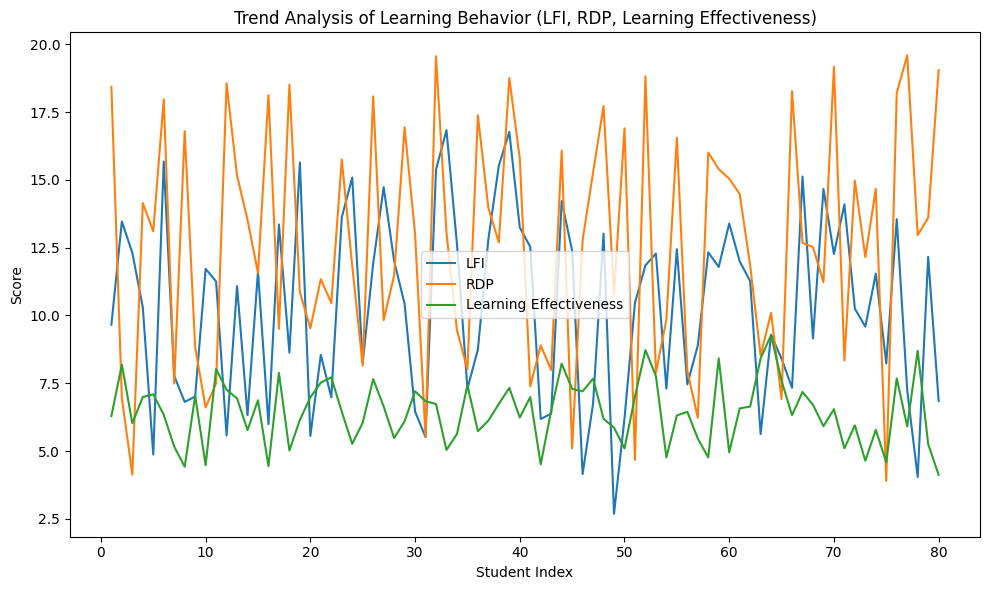

In [19]:
import matplotlib.pyplot as plt

# Sort data (important for trend)
df_sorted = df.sort_values(by='Student_ID')

# Plot trends
plt.figure(figsize=(10,6))

plt.plot(df_sorted['Student_ID'], df_sorted['LFI'], label='LFI')
plt.plot(df_sorted['Student_ID'], df_sorted['RDP'], label='RDP')
plt.plot(df_sorted['Student_ID'], df_sorted['Learning Effectiveness'], label='Learning Effectiveness')

# Labels
plt.xlabel('Student Index')
plt.ylabel('Score')
plt.title('Trend Analysis of Learning Behavior (LFI, RDP, Learning Effectiveness)')
plt.legend()

plt.tight_layout()
plt.show()